In [1]:
print("Task 3 notebook ready")

Task 3 notebook ready


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error

print("Libraries loaded")

Libraries loaded


In [3]:
df = pd.read_csv("../data/PJME_prepared.csv")

df["Datetime"] = pd.to_datetime(df["Datetime"])

df = df.sort_values("Datetime")

df.head()

,Datetime,PJME_MW
8734,2002-01-01 01:00:00,30393.0
8735,2002-01-01 02:00:00,29265.0
8736,2002-01-01 03:00:00,28357.0
8737,2002-01-01 04:00:00,27899.0
8738,2002-01-01 05:00:00,28057.0


In [4]:
df["hour"] = df["Datetime"].dt.hour
df["dayofweek"] = df["Datetime"].dt.dayofweek
df["month"] = df["Datetime"].dt.month

df["lag_24"] = df["PJME_MW"].shift(24)
df["lag_168"] = df["PJME_MW"].shift(168)

df.head()

,Datetime,PJME_MW,hour,dayofweek,month,lag_24,lag_168
8734,2002-01-01 01:00:00,30393.0,1,1,1,NaN,NaN
8735,2002-01-01 02:00:00,29265.0,2,1,1,NaN,NaN
8736,2002-01-01 03:00:00,28357.0,3,1,1,NaN,NaN
8737,2002-01-01 04:00:00,27899.0,4,1,1,NaN,NaN
8738,2002-01-01 05:00:00,28057.0,5,1,1,NaN,NaN


In [5]:
df_ml = df.dropna()

print(df_ml.shape)

(145198, 7)


In [6]:
features = [
    "hour",
    "dayofweek",
    "month",
    "lag_24",
    "lag_168"
]

X = df_ml[features]

y = df_ml["PJME_MW"]

print(X.shape)
print(y.shape)

(145198, 5)
(145198,)


In [7]:
split_idx = int(len(df_ml) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print(X_train.shape)
print(X_test.shape)

(116158, 5)
(29040, 5)


In [8]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Model trained")

Model trained


In [9]:
from sklearn.metrics import mean_absolute_error

mae_lr = mean_absolute_error(
    y_test,
    pred_lr
)

print("MAE Linear Regression =", round(mae_lr, 2))

MAE Linear Regression = 1968.86


Использование признаков временного ряда (feature engineering) позволило существенно повысить качество прогноза. Линейная регрессия показала среднюю абсолютную ошибку 1968.86 МВт, что значительно лучше результатов статистических моделей.

In [10]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(
    y_test,
    pred_rf
)

print("MAE Random Forest =", round(mae_rf, 2))

MAE Random Forest = 1859.95


In [11]:
from xgboost import XGBRegressor

print("XGBoost loaded")

XGBoost loaded


In [12]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

xgb = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

mae_xgb = mean_absolute_error(
    y_test,
    pred_xgb
)

print("MAE XGBoost =", round(mae_xgb, 2))

MAE XGBoost = 1770.91


Визуализация прогноза XGBoost

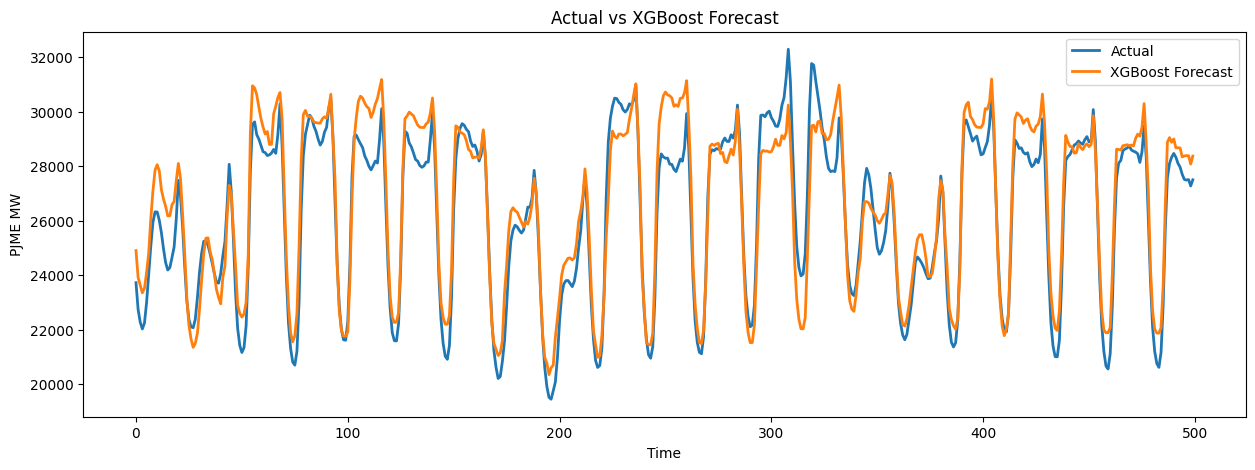

In [13]:
plt.figure(figsize=(15, 5))

plt.plot(
    y_test.values[:500],
    label="Actual",
    linewidth=2
)

plt.plot(
    pred_xgb[:500],
    label="XGBoost Forecast",
    linewidth=2
)

plt.title("Actual vs XGBoost Forecast")
plt.xlabel("Time")
plt.ylabel("PJME MW")
plt.legend()

plt.show()

In [14]:
print(type(y_test))
print(type(pred_xgb))
print(len(y_test))
print(len(pred_xgb))

<class 'pandas.core.series.Series'>
<class 'numpy.ndarray'>
29040
29040


In [15]:
print("hello")

hello


In [16]:
df_anomaly = df.copy()

print(df_anomaly.shape)

(145366, 7)


In [17]:
from scipy.stats import zscore

df_anomaly["z_score"] = zscore(df_anomaly["PJME_MW"])

anomalies_z = df_anomaly[
    abs(df_anomaly["z_score"]) > 3
]

print("Количество аномалий:", len(anomalies_z))

Количество аномалий: 1318


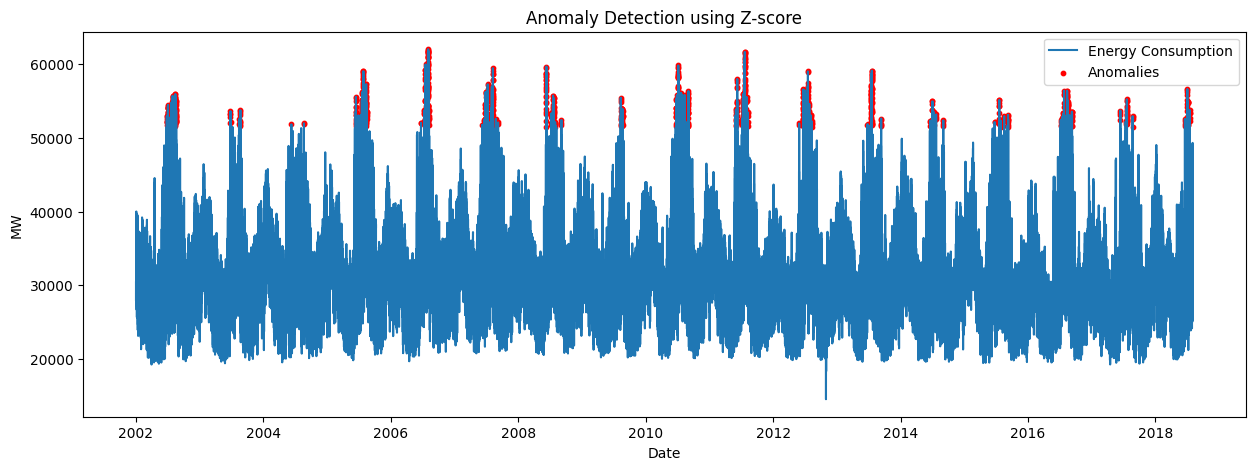

In [18]:
plt.figure(figsize=(15, 5))

plt.plot(
    df_anomaly["Datetime"],
    df_anomaly["PJME_MW"],
    label="Energy Consumption"
)

plt.scatter(
    anomalies_z["Datetime"],
    anomalies_z["PJME_MW"],
    color="red",
    s=10,
    label="Anomalies"
)

plt.title("Anomaly Detection using Z-score")
plt.xlabel("Date")
plt.ylabel("MW")
plt.legend()

plt.show()

In [19]:
Q1 = df_anomaly["PJME_MW"].quantile(0.25)
Q3 = df_anomaly["PJME_MW"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

anomalies_iqr = df_anomaly[
    (df_anomaly["PJME_MW"] < lower_bound) |
    (df_anomaly["PJME_MW"] > upper_bound)
]

print("Количество аномалий (IQR):", len(anomalies_iqr))

Количество аномалий (IQR): 3455


In [20]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(
    contamination=0.01,
    random_state=42
)

df_anomaly["iso_flag"] = iso_forest.fit_predict(
    df_anomaly[["PJME_MW"]]
)

anomalies_iso = df_anomaly[
    df_anomaly["iso_flag"] == -1
]

print("Количество аномалий (Isolation Forest):", len(anomalies_iso))

Количество аномалий (Isolation Forest): 1452


In [21]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error

mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPRegressor(
        hidden_layer_sizes=(64, 32),
        max_iter=50,
        random_state=42,
        early_stopping=True
    ))
])

mlp.fit(X_train, y_train)

pred_mlp = mlp.predict(X_test)

mae_mlp = mean_absolute_error(y_test, pred_mlp)

print("MAE MLP =", round(mae_mlp, 2))

MAE MLP = 1871.09


C:\Users\kates\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


In [22]:
mlp_large = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPRegressor(
        hidden_layer_sizes=(128, 64, 32),
        max_iter=50,
        random_state=42,
        early_stopping=True
    ))
])

mlp_large.fit(X_train, y_train)

pred_mlp_large = mlp_large.predict(X_test)

mae_mlp_large = mean_absolute_error(y_test, pred_mlp_large)

print("MAE MLP Large =", round(mae_mlp_large, 2))

MAE MLP Large = 1865.52


C:\Users\kates\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


In [23]:
mlp_deep = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPRegressor(
        hidden_layer_sizes=(128, 128, 64, 32),
        activation="relu",
        max_iter=50,
        random_state=42,
        early_stopping=True
    ))
])

mlp_deep.fit(X_train, y_train)

pred_mlp_deep = mlp_deep.predict(X_test)

mae_mlp_deep = mean_absolute_error(y_test, pred_mlp_deep)

print("MAE MLP Deep =", round(mae_mlp_deep, 2))

MAE MLP Deep = 1805.11


C:\Users\kates\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
